In [21]:
# --- Sistem / čas
from datetime import datetime, timedelta
from typing import Any
from copy import deepcopy as dc

# --- Osnovne knjižnice
import pandas as pd
import numpy as np
import joblib

# --- PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from optuna.integration import PyTorchLightningPruningCallback
from sklearn.preprocessing import MinMaxScaler

# --- PyTorch Forecasting + Lightning
import lightning as pl
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.utilities.types import OptimizerLRScheduler

from pytorch_forecasting import (
    TimeSeriesDataSet,
    NaNLabelEncoder,
    QuantileLoss
)
import optuna
# --- Lion optimizer
from lion_pytorch import Lion

# --- Optuna in TensorBoard (če še ni nameščen)
# !pip install tensorboard optuna optuna-integration pytorch-lightning

In [10]:
class QuantileLSTM(pl.LightningModule):
    def __init__(self, prediction_length, input_size, hidden_size, num_layers=2,
                 quantiles=[0.1, 0.5, 0.9], dropout=0.2, lr=1e-3, weight_decay=0.0,
                 beta1=0.9, beta2=0.999):
        super().__init__()
        self.save_hyperparameters()
        self.prediction_length = prediction_length
        self.quantiles = quantiles
        self.lr = lr
        self.weight_decay = weight_decay
        self.beta1 = beta1
        self.beta2 = beta2

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )

        self.ln = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, prediction_length * len(quantiles))
        self.init_weights()
        self.quantile_loss = QuantileLoss(quantiles)

        self.train_losses = []
        self.val_losses = []

    def init_weights(self):
        for name, param in self.lstm.named_parameters():
            if "weight" in name:
                nn.init.xavier_uniform_(param)
            elif "bias" in name:
                nn.init.zeros_(param)
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_hidden = lstm_out[:, -1, :]  # [B, hidden]
        normed = self.ln(last_hidden)     # Apply batchnorm
        out = self.fc(normed)
        return out.view(-1, self.prediction_length, len(self.quantiles))

    @classmethod
    def from_dataset(cls, dataset, hidden_size=64, num_layers=2, dropout=0.2,
                     quantiles=[0.1, 0.5, 0.9], lr=1e-3, weight_decay=0.0,
                     beta1=0.9, beta2=0.999):
        return cls(
            prediction_length=dataset.max_prediction_length,
            input_size=len(dataset.reals),
            hidden_size=hidden_size,
            num_layers=num_layers,
            quantiles=quantiles,
            dropout=dropout,
            lr=lr,
            weight_decay=weight_decay,
            beta1=beta1,
            beta2=beta2
        )

    def configure_optimizers(self):
        optimizer = Lion(
            self.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay,
            betas=(self.beta1, self.beta2)
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=5, factor=0.5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss",
                "frequency": 1
            }
        }

    def training_step(self, batch, batch_idx):
        x, y = batch
        x_cont = x["encoder_cont"]
        y_hat = self(x_cont)
       # y_true = y[0][:, -self.prediction_length:]
        y_true = y[0][:, -self.prediction_length:]

        loss = self.quantile_loss(y_hat, y_true)
        self.train_losses.append(loss.detach().cpu().item())
        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x_cont = x["encoder_cont"]
        y_hat = self(x_cont)
       # y_true = y[0][:, :self.prediction_length]
        y_true = y[0][:, -self.prediction_length:]
        loss = self.quantile_loss(y_hat, y_true)
        self.train_losses.append(loss.detach().cpu().item())
        self.log("val_loss", loss, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x, _ = batch
        x_cont = x["encoder_cont"]
        predictions = self(x_cont)
        return {
            "quantile_predictions": predictions,
            "quantiles": self.quantiles,
            "prediction_length": self.prediction_length
        }

In [11]:
df = pd.read_csv("Data/daily_data_cleaned.csv", parse_dates=['Date'])
df = df[df.Date <= datetime.today() ]
# --- Pretvori kategorije
cat_cols = [
    'US', 'UK', 'Japan', 'China', 'day', 'month', 'day_of_week', 'week_of_year',
    'year', 'quarter', 'is_weekend', 'is_month_end', 'Halving', 'group'
]
df[cat_cols] = df[cat_cols].astype(str).astype("category")

# --- Poskrbi za time_idx in indeks
df["time_idx"] = df["time_idx"].astype(int)
df = df.sort_values("Date")
df.index = pd.to_datetime(df["Date"])
df = df.drop(columns=["Date"])

# --- Skaliraj target "Close"
scaler = MinMaxScaler()
df["Close"] = scaler.fit_transform(df[["Close"]])
joblib.dump(scaler, "close_minmax_scaler.pkl")

# --- Kopija za nadaljnje ločevanje
df_tmp = dc(df)

# --- Nastavi dolžine
max_encoder_length = 120
max_prediction_length = 31

# --- Loči trening in test
cutoff_date = datetime.today() - timedelta(days=max_encoder_length + max_prediction_length)
df_train = df_tmp[df_tmp.index <= cutoff_date].copy()
df_test = df_tmp[df_tmp.index > cutoff_date].copy()

# --- Oba seta naj imata 'group' in 'time_idx' pravilno nastavljena
df_train["group"] = "BTC"
df_test["group"] = "BTC"
df_train["time_idx"] = df_train["time_idx"].astype(int)
df_test["time_idx"] = df_test["time_idx"].astype(int)

# --- Prikaz
print("Train:", df_train.shape, "| Test:", df_test.shape)

Train: (291, 110) | Test: (151, 110)


In [7]:
df_train

,Close,High,Low,Open,Volume,BTC_miners,BTC_transactions,BTC_network,Unique Addresses Used,Number of Transactions,...,time_idx,Halving,Volume_weekly,Volume_monthly,MA7,MA111,MA200,Close_delta_1,Close_delta_7,group
Date,,,,,,,,,,,,,,,,,,,,,
2024-01-13,0.050046,0.045042,0.059042,0.049239,0.080485,0.053892,0.375576,0.245994,0.669187,0.242622,...,1,0,0.251305,0.054553,0.071083,0.000000,0.000000,0.497983,0.361942,BTC
2024-01-14,0.034348,0.042591,0.047967,0.049882,0.058462,0.054633,0.286704,0.269356,0.669187,0.242622,...,2,0,0.251305,0.054553,0.066246,0.002316,0.000952,0.434892,0.332987,BTC
2024-01-15,0.045088,0.046275,0.047679,0.032964,0.092770,0.055374,0.184123,0.292719,0.715233,0.242622,...,3,0,0.216541,0.054553,0.056202,0.004750,0.001933,0.542254,0.266054,BTC
2024-01-16,0.054736,0.049848,0.053379,0.044735,0.105229,0.055903,0.139656,0.248572,0.761279,0.264558,...,4,0,0.181777,0.054553,0.049477,0.007261,0.002963,0.537823,0.308725,BTC
2024-01-17,0.048549,0.044393,0.054926,0.054232,0.082268,0.056431,0.298576,0.204396,0.807325,0.286494,...,5,0,0.147014,0.054553,0.040725,0.009610,0.003951,0.473516,0.282656,BTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-10-25,0.407195,0.414492,0.404373,0.429944,0.229676,0.016700,0.351459,0.239840,0.243010,0.436554,...,287,0,0.165483,0.164724,0.426106,0.417159,0.492793,0.406097,0.343714,BTC
2024-10-26,0.412782,0.394137,0.416935,0.406883,0.073237,0.019390,0.337395,0.232122,0.304016,0.474734,...,288,0,0.158846,0.166727,0.423069,0.418828,0.492620,0.521327,0.356116,BTC
2024-10-27,0.426507,0.407232,0.424223,0.412807,0.052742,0.022081,0.323332,0.224404,0.365022,0.512914,...,289,0,0.152209,0.168731,0.420653,0.420505,0.492404,0.554375,0.364097,BTC


In [6]:
df_test

,Close,High,Low,Open,Volume,BTC_miners,BTC_transactions,BTC_network,Unique Addresses Used,Number of Transactions,...,time_idx,Halving,Volume_weekly,Volume_monthly,MA7,MA111,MA200,Close_delta_1,Close_delta_7,group
Date,,,,,,,,,,,,,,,,,,,,,
2024-10-30,0.492688,0.475129,0.492585,0.498234,0.223790,0.017299,0.374007,0.214074,0.458324,0.559739,...,292,0,0.213397,0.174743,0.451757,0.426761,0.493533,0.475426,0.566190,BTC
2024-10-31,0.460809,0.471606,0.465309,0.492526,0.223656,0.013876,0.419233,0.237072,0.474472,0.530204,...,293,0,0.233793,0.176747,0.456385,0.428601,0.493897,0.369186,0.454623,BTC
2024-11-01,0.449814,0.455614,0.453166,0.460736,0.290586,0.007030,0.518790,0.283085,0.490619,0.500669,...,294,0,0.254188,0.204189,0.462784,0.430133,0.494389,0.453990,0.477379,BTC
2024-11-02,0.446915,0.431092,0.456970,0.449767,0.063203,0.005646,0.458530,0.333767,0.484303,0.471135,...,295,0,0.274584,0.231630,0.467908,0.431403,0.494835,0.486868,0.461006,BTC
2024-11-03,0.438689,0.423762,0.433738,0.446920,0.182479,0.004250,0.277921,0.322993,0.477987,0.453099,...,296,0,0.294980,0.259072,0.469737,0.431981,0.495441,0.465237,0.418653,BTC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,0.719765,0.701794,0.716254,0.720323,0.147716,0.008391,0.010903,0.338968,0.431317,0.379048,...,438,0,0.067172,0.289070,0.711308,0.967854,0.849306,0.496982,0.532772,BTC
2025-03-26,0.711199,0.698167,0.708996,0.719534,0.124111,0.008607,0.079462,0.302167,0.431317,0.421535,...,439,0,0.081169,0.281963,0.711413,0.966405,0.851969,0.463856,0.396498,BTC
2025-03-27,0.715344,0.690840,0.708644,0.711069,0.107735,0.008705,0.137901,0.313341,0.431317,0.421535,...,440,0,0.095167,0.274856,0.718194,0.964501,0.854597,0.515473,0.482297,BTC


In [13]:
%load_ext tensorboard
%reload_ext tensorboard
%tensorboard --logdir='lightning_logs/' --port=6004

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [14]:
# === Known Reals ===
time_varying_known_reals = [
       'GDP and National Income', 'Personal Income and Employment',
       'Industry Specific Accounts', 'Fixed Assets and Investment',
       'Trade and International Transactions', 'Government and Public Sector',
       'Financial and Corporate Data',
       "time_idx"
]

# === Unknown Reals ===
time_varying_unknown_reals = [
    "High", "Low", "Open", "Volume", "BTC_miners",
    "BTC_transactions", "BTC_network", "Unique Addresses Used",
    "Number of Transactions", "Transactions Per Second", "Output Volume",
    "Mempool Transaction Count", "Mempool Size Growth", "Mempool Size (Bytes)",
    "Transactions Excluding Popular Addresses", "Estimated Transaction Volume (BTC)",
    "Estimated Transaction Volume (USD)", "Miners Revenue (USD)",
    "Transaction Fees (BTC)", "Transaction Fees (USD)",
    "Cost per Transaction (%)", "Cost per Transaction (USD)",
    "Network Difficulty", "Hash Rate (TH/s)", "Block Size",
    "Average Block Size", "Transactions per Block", "Trade Volume",
    "Total Bitcoins", "Market Cap", "M2SL", "M1SL", "WALCL", "CPIAUCSL",
    "CPILFESL", "CUSR0000SA0L2", "FEDFUNDS", "IRLTLT01JPM156N", "PAYEMS",
    "UNRATE", "CIVPART", "DSPIC96", "PCE", "PSAVERT", "GEPUCURRENT",
    "USEPUINDXD", "EPUMONETARY", "APU000072610", "CPIENGSL", "HOUST",
    "PERMIT", "RECPROUSM156N", "DTWEXBGS", "DGS10", "DGS2", "DGS30",
    "T10Y2Y", "T10Y3M", "T10YIE", "DFF", "SP500", "VIXCLS", "NASDAQCOM",
    "BAA10Y", "DCOILWTICO", "WLEMUINDXD", "T5YIFR", "Close"
]


# === Known Categoricals ===
time_varying_known_categoricals = [
       'US', 'UK', 'Japan','China', 'day', 'month', 'day_of_week', 'week_of_year', 'year',
       'quarter', 'is_weekend', 'is_month_end', 'Halving'
]

static_categoricals = ["group"]


In [76]:

params = {'hidden_size': 96, 'num_layers': 3, 'dropout': 0.44448338492939043, 'lr': 0.0018635148708637124, 'weight_decay': 9.890917462646941e-06, 'beta1': 0.930253303590372, 'beta2': 0.9596305137040889, 'clip_val': 0.8857687055498911, 'batch_size': 32}


training_cutoff = df["time_idx"].max() - max_prediction_length

pl.seed_everything(42, workers=True)

training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Close",
    group_ids=static_categoricals,
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=[],
    time_varying_unknown_reals=time_varying_known_reals + time_varying_unknown_reals,
    time_varying_known_categoricals=[],
    static_categoricals=[],
    add_relative_time_idx=True,
    add_target_scales=False,
    add_encoder_length=True,
    categorical_encoders={col: NaNLabelEncoder(add_nan=True) for col in time_varying_known_categoricals},
)

validation = TimeSeriesDataSet.from_dataset(
    training, df, predict=True, stop_randomization=True
)

# create dataloaders for model
batch_size = params["batch_size"]  # set this between 32 to 128
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size, num_workers=7,persistent_workers=True
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10, num_workers=7,persistent_workers=True
)


model = QuantileLSTM.from_dataset(
    training,
    hidden_size=params["hidden_size"],
    num_layers=params["num_layers"],
    dropout=params["dropout"],
    quantiles=[0.1, 0.5, 0.9],
    lr=params["lr"],
    weight_decay=params["weight_decay"],
    beta1=params["beta1"],
    beta2=params["beta2"]
)

logger = TensorBoardLogger("lightning_logs", name="lstm")

early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min")

trainer = Trainer(
    max_epochs=300,
    logger=logger,
    callbacks=[early_stop, checkpoint],
    log_every_n_steps=10,
    accelerator="gpu",
    enable_model_summary=True,
    gradient_clip_val=params["clip_val"],
)

trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name          | Type         | Params | Mode 
-------------------------------------------------------
0 | lstm          | LSTM         | 216 K  | train
1 | ln            | LayerNorm    | 192    | train
2 | fc            | Linear       | 9.0 K  | train
3 | quantile_loss | QuantileLoss | 0      | train
-------------------------------------------------------
225 K     Trainable params
0         Non-trainable params
225 K     Total params
0.903     Total estimated model params size (MB)
4         Modules in train mode
0         Modules in eval mode


/opt/anaconda3/envs/flaskProject/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 0: 100%|██████████| 4/4 [00:03<00:00,  1.20it/s, v_num=9, train_loss=0.300]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 4/4 [00:00<00:00, 30.44it/s, v_num=9, train_loss=0.141, val_loss=0.296]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 4/4 [00:00<00:00, 32.40it/s, v_num=9, train_loss=0.118, val_loss=0.205]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 4/4 [00:00<00:00, 32.93it/s, v_num=9, train_loss=0.089, val_loss=0.222] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 4/4 [00:00<00:00, 34.47it/s, v_num=9, train_loss=0.0745, val_loss=0.242]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 4/4 [00:00<00:00, 34.13it/s, v_num=9, train_loss=0.0682, val_loss=0.288]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 4/4 [00:00<00:00, 36.49it/s, v_num=9, train_loss=0.0574, val_loss=0.277]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoc

In [37]:
len(df_test)

43

In [79]:
test = TimeSeriesDataSet(
    df_test,
    time_idx="time_idx",
    target="Close",
    group_ids=static_categoricals,
    max_encoder_length=119,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=[],
    time_varying_unknown_reals=time_varying_known_reals + time_varying_unknown_reals,
    time_varying_known_categoricals=[],
    static_categoricals=[],
    add_relative_time_idx=True,
    add_target_scales=False,
    add_encoder_length=True,
     categorical_encoders={col: NaNLabelEncoder(add_nan=True) for col in time_varying_known_categoricals},
)

In [80]:
preds = trainer.predict(model, dataloaders=[test.to_dataloader(train=False, batch_size=120)])
preds

/opt/anaconda3/envs/flaskProject/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 59.79it/s]


[{'quantile_predictions': tensor([[[0.2684, 0.3181, 0.4811],
           [0.2930, 0.2969, 0.5400],
           [0.2696, 0.2998, 0.5525],
           [0.2164, 0.3645, 0.4165],
           [0.2479, 0.3031, 0.5699],
           [0.2146, 0.3132, 0.6283],
           [0.3102, 0.3636, 0.3966],
           [0.3333, 0.3136, 0.5525],
           [0.3162, 0.3104, 0.4596],
           [0.2902, 0.3934, 0.4970],
           [0.2645, 0.3673, 0.4708],
           [0.2240, 0.3860, 0.4147],
           [0.1467, 0.3579, 0.4032],
           [0.1898, 0.3184, 0.4196],
           [0.1952, 0.3669, 0.5301],
           [0.2203, 0.2977, 0.4645],
           [0.2336, 0.3289, 0.4777],
           [0.2241, 0.3822, 0.4007],
           [0.2825, 0.3497, 0.6793],
           [0.2224, 0.3733, 0.4976],
           [0.1871, 0.3569, 0.3947],
           [0.1942, 0.2703, 0.3766],
           [0.2094, 0.3444, 0.4147],
           [0.2445, 0.3384, 0.4308],
           [0.2981, 0.3140, 0.4383],
           [0.2920, 0.3531, 0.3724],
           [0.

In [50]:
preds = trainer.predict(model, dataloaders=val_dataloader, return_predictions=True)
preds

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 25.16it/s]


[{'quantile_predictions': tensor([[[0.8167, 0.8955, 0.9552],
           [0.8188, 0.8801, 0.9968],
           [0.7649, 0.9168, 0.9831],
           [0.8476, 0.8962, 0.9876],
           [0.8561, 0.9226, 0.9756],
           [0.8464, 0.8899, 0.9713],
           [0.8720, 0.8754, 0.9883],
           [0.8330, 0.9041, 0.9770],
           [0.8566, 0.8892, 1.0063],
           [0.8320, 0.8955, 0.9502],
           [0.7953, 0.8544, 0.9531],
           [0.8417, 0.9059, 0.9447],
           [0.8361, 0.8726, 0.9899],
           [0.8182, 0.8794, 0.9908]]]),
  'quantiles': [0.1, 0.5, 0.9],
  'prediction_length': 14}]

MSE: 629061120.0000
MAE: 22592.8984
R²: -4.5344


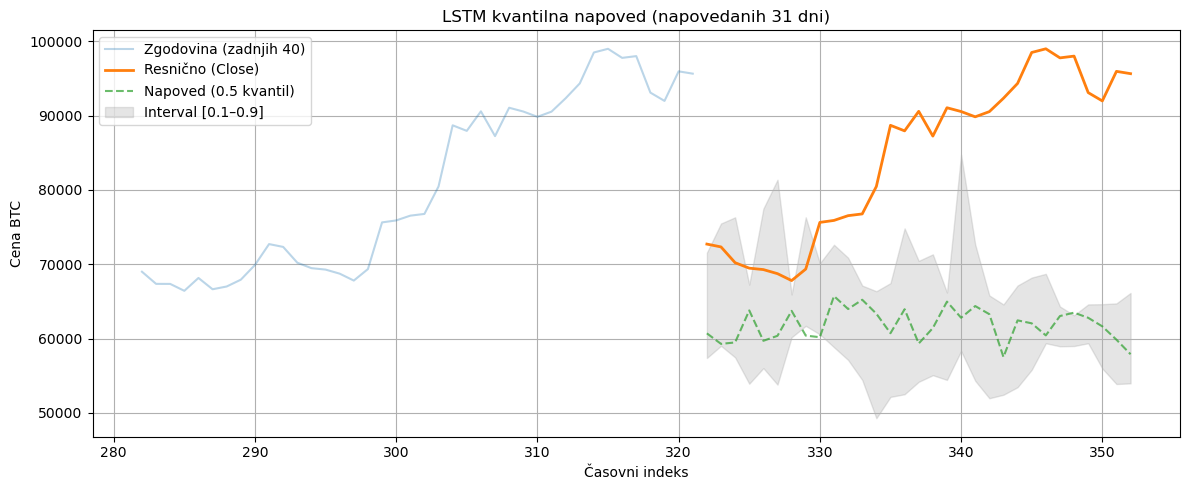

In [81]:
import joblib
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Naloži scaler
scaler = joblib.load("close_minmax_scaler.pkl")

# --- Napovedi (inverz MinMax namesto exp)
pred_result = preds[0]
y_pred = pred_result["quantile_predictions"].squeeze(0).detach().cpu().numpy()  # [prediction_length, 3]
y_pred = scaler.inverse_transform(y_pred)

quantiles = pred_result["quantiles"]
prediction_length = pred_result["prediction_length"]

# --- Prava vrednost (iz batcha)
_, y = next(iter(val_dataloader))
y_true = y[0][0, :prediction_length].detach().cpu().numpy()
y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).flatten()

# --- Metrike za 0.5 kvantil
mse = mean_squared_error(y_true, y_pred[:, 1])
mae = mean_absolute_error(y_true, y_pred[:, 1])
r2 = r2_score(y_true, y_pred[:, 1])

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# --- Pripravi zgodovinske podatke (zadnjih 40 time_idx)
history_df = df.sort_values("time_idx").copy()
history_df = history_df.iloc[-40:]  # zadnjih 40 vrstic
history_time = history_df["time_idx"].values
history_close = scaler.inverse_transform(history_df["Close"].values.reshape(-1, 1)).flatten()

# --- Indeksi za napovedi (nadaljujejo po zgodovini)
x_range = list(range(history_time.max() + 1, history_time.max() + 1 + prediction_length))
# --- Vizualizacija
plt.figure(figsize=(12, 5))
plt.plot(history_time, history_close, label="Zgodovina (zadnjih 40)", alpha=0.3)
plt.plot(x_range, y_true, label="Resnično (Close)", linewidth=2)
plt.plot(x_range, y_pred[:, 1], label="Napoved (0.5 kvantil)", linestyle="--", alpha=0.7)

# --- Senčen pas med 0.1 in 0.9 kvantilom
plt.fill_between(x_range, y_pred[:, 0], y_pred[:, 2], color="gray", alpha=0.2, label="Interval [0.1–0.9]")

plt.title("LSTM kvantilna napoved (napovedanih 31 dni)")
plt.xlabel("Časovni indeks")
plt.ylabel("Cena BTC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [42]:
y_pred


array([[102517.85 , 106207.766, 146709.64 ],
       [ 74512.016, 116533.23 , 159498.19 ],
       [ 75125.57 , 105824.18 , 134042.22 ],
       [ 84838.85 , 115099.805, 146492.66 ],
       [ 82685.67 , 124112.99 , 145594.45 ],
       [ 82369.36 , 106146.71 , 151140.53 ],
       [100367.805, 116485.336, 160094.5  ],
       [ 96627.586, 106496.42 , 172737.5  ],
       [109143.63 , 113684.45 , 130030.48 ],
       [ 88689.41 , 108224.266, 160959.   ],
       [ 75783.34 , 120684.31 , 151718.19 ],
       [ 89373.16 , 113128.875, 132409.1  ],
       [ 83229.5  , 115226.22 , 152117.47 ],
       [ 93669.68 , 110147.35 , 135889.88 ],
       [102562.64 , 116616.164, 147262.92 ],
       [ 79606.125, 108899.51 , 177056.94 ],
       [ 96343.17 , 115486.07 , 169217.06 ],
       [ 92085.2  , 118230.49 , 175437.47 ],
       [ 90740.5  , 110701.91 , 172296.23 ],
       [ 87799.04 , 116289.2  , 173327.6  ],
       [ 86777.88 , 118663.35 , 179900.06 ],
       [ 84284.984, 121794.87 , 128908.87 ],
       [ 8

In [43]:
y_true

array([84343.12 , 82579.68 , 84075.695, 82718.48 , 86854.22 , 84167.23 ,
       84043.23 , 83832.45 , 86054.39 , 87498.95 , 87471.67 , 86900.87 ,
       87177.12 , 85122.5  ], dtype=float32)

MSE: 0.0232
MAE: 0.1395
R²: -18.2364


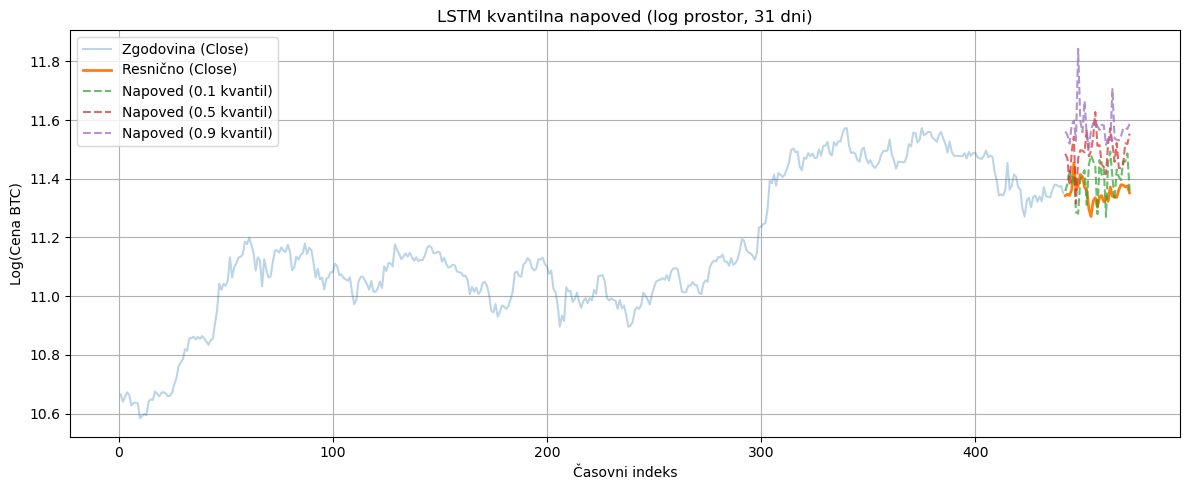

In [483]:
# --- Iz podatkov
pred_result = preds[0]
y_pred = pred_result["quantile_predictions"].squeeze(0).detach().cpu().numpy()  # [31, 3]

quantiles = pred_result["quantiles"]
prediction_length = pred_result["prediction_length"]

# --- Prava vrednost (1 batch iz val_dataloader)
_, y = next(iter(val_dataloader))
y_true = y[0][0, :prediction_length].detach().cpu().numpy()

# --- Metrike za 0.5 kvantil
mse = mean_squared_error(y_true, y_pred[:, 1])
mae = mean_absolute_error(y_true, y_pred[:, 1])
r2 = r2_score(y_true, y_pred[:, 1])

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

# --- Začetek napovedi
start_idx = df_train["time_idx"].max() + 1
x_range = range(start_idx, start_idx + prediction_length)

# --- Graf
plt.figure(figsize=(12, 5))
plt.plot(df_train["time_idx"], df_train["Close"], label="Zgodovina (Close)", alpha=0.3)
plt.plot(x_range, y_true, label="Resnično (Close)", linewidth=2)
plt.plot(x_range, y_pred[:, 0], label="Napoved (0.1 kvantil)", linestyle="--", alpha=0.7)
plt.plot(x_range, y_pred[:, 1], label="Napoved (0.5 kvantil)", linestyle="--", alpha=0.7)
plt.plot(x_range, y_pred[:, 2], label="Napoved (0.9 kvantil)", linestyle="--", alpha=0.7)

plt.title("LSTM kvantilna napoved (log prostor, 31 dni)")
plt.xlabel("Časovni indeks")
plt.ylabel("Log(Cena BTC)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
def objective(trial):
    # --- Hiperparametri v params slovarju
    params = {
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "hidden_size": trial.suggest_categorical("hidden_size", [64, 128, 160, 192, 224, 256, 288, 320]),
        "hidden_continuous_size": trial.suggest_categorical("hidden_continuous_size", [8, 16, 24, 32, 48, 64, 80]),
        "attention_head_size": trial.suggest_int("attention_head_size", 1, 8),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "clip_val": trial.suggest_float("gradient_clip_val", 0.05, 1.0),
        "weight_decay": trial.suggest_float("weight_decay", 1e-8, 1e-4, log=True),
        "beta1": trial.suggest_float("beta1", 0.85, 0.95),
        "beta2": trial.suggest_float("beta2", 0.95, 0.999),
        "batch_size": trial.suggest_categorical("batch_size", [8, 16, 32, 64]),
        "max_encoder_length": trial.suggest_categorical("max_encoder_length", [30, 45, 60, 75, 90, 105, 120, 150]),
    }

    max_prediction_length = 31
    training_cutoff = df["time_idx"].max() - max_prediction_length
    pl.seed_everything(42, workers=True)

    # --- Priprava podatkov
    training = TimeSeriesDataSet(
        df[df.time_idx <= training_cutoff],
        time_idx="time_idx",
        target="Close",
        group_ids=["group"],
        max_encoder_length=params["max_encoder_length"],
        max_prediction_length=max_prediction_length,
        time_varying_known_reals=time_varying_known_reals,
        time_varying_unknown_reals=time_varying_unknown_reals,
        time_varying_known_categoricals=[],
        static_categoricals=[],
        add_relative_time_idx=True,
        add_encoder_length=True,
        add_target_scales=False,
        target_normalizer=None,
    )

    validation = TimeSeriesDataSet.from_dataset(
        training, df, predict=True, stop_randomization=True
    )

    train_dataloader = training.to_dataloader(train=True, batch_size=params["batch_size"], num_workers=7, persistent_workers=True)
    val_dataloader = validation.to_dataloader(train=False, batch_size=params["batch_size"] * 10, num_workers=7, persistent_workers=True)

    # --- Model
    model = QuantileLSTM.from_dataset(
        training,
        hidden_size=params["hidden_size"],
        num_layers=3,  # ali poskusi s trial.suggest_int("num_layers", ...)
        dropout=params["dropout"],
        quantiles=[0.1, 0.5, 0.9],
        lr=params["lr"],
        weight_decay=params["weight_decay"],
        beta1=params["beta1"],
        beta2=params["beta2"]
    )
 
    early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min",verbose=False)
    checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min")
    pruning_callback = PyTorchLightningPruningCallback(trial, monitor="val_loss")

    # --- Treniranje
    trainer = Trainer(
        max_epochs=100,
        callbacks=[early_stop, checkpoint, pruning_callback],
        log_every_n_steps=10,
        accelerator="gpu",
        enable_model_summary=False,
        gradient_clip_val=params["clip_val"],
    )

    trainer.fit(model, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

    # --- Rezultat
    val_loss = trainer.callback_metrics.get("val_loss")
    if val_loss is None:
        return float("inf")
    return val_loss.item()

In [ ]:
import optuna

study = optuna.create_study(direction="minimize") 
study.optimize(objective, n_trials=200)  

[I 2025-03-29 16:02:11,465] A new study created in memory with name: no-name-bed1a116-6377-4223-8587-dad1e9a87c64
Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 0: 100%|██████████| 10/10 [00:03<00:00,  2.62it/s, v_num=0, train_loss=0.218]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 10/10 [00:00<00:00, 53.97it/s, v_num=0, train_loss=0.117, val_loss=0.183]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2: 100%|██████████| 10/10 [00:00<00:00, 54.52it/s, v_num=0, train_loss=0.0872, val_loss=0.122]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 3: 100%|██████████| 10/10 [00:00<00:00, 63.44it/s, v_num=0, train_loss=0.0647, val_loss=0.134]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 4: 100%|██████████| 10/10 [00:00<00:00, 59.54it/s, v_num=0, train_loss=0.0548, val_loss=0.114]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 5: 100%|██████████| 10/10 [00:00<00:00, 62.20it/s, v_num=0, train_loss=0.047, val_loss=0.124] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 6: 100%|██████████| 10/10 [00:00<00:00, 56.28it/s, v_num=0, train_loss=0.0497, val_loss=0.126]
Validation: |          | 0/? [00:00

[I 2025-03-29 16:02:25,643] Trial 0 finished with value: 0.16162019968032837 and parameters: {'lr': 0.001170314113697417, 'hidden_size': 64, 'hidden_continuous_size': 8, 'attention_head_size': 5, 'dropout': 0.48018891167450456, 'gradient_clip_val': 0.7031703408530531, 'weight_decay': 5.667445562195801e-05, 'beta1': 0.9091131561556156, 'beta2': 0.9621466490170621, 'batch_size': 32, 'max_encoder_length': 30}. Best is trial 0 with value: 0.16162019968032837.
Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Epoch 0: 100%|██████████| 34/34 [00:05<00:00,  6.39it/s, v_num=1, train_loss=0.158]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 1: 100%|██████████| 34/34 [00:01<00:00, 28.24it/s, v_num=1, train_loss=0.096, val_loss=0.189] 
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 2:  12%|█▏        | 4/34 [00:00<00:01, 26.49it/s, v_num=1, train_loss=0.0911, val_loss=0.139]

In [22]:
print(study.best_trial.params)

{'hidden_size': 96, 'num_layers': 3, 'dropout': 0.44448338492939043, 'lr': 0.0018635148708637124, 'weight_decay': 9.890917462646941e-06, 'beta1': 0.930253303590372, 'beta2': 0.9596305137040889, 'clip_val': 0.8857687055498911, 'batch_size': 32}


In [23]:
print(study.best_trial.params)

{'hidden_size': 96, 'num_layers': 3, 'dropout': 0.44448338492939043, 'lr': 0.0018635148708637124, 'weight_decay': 9.890917462646941e-06, 'beta1': 0.930253303590372, 'beta2': 0.9596305137040889, 'clip_val': 0.8857687055498911, 'batch_size': 32}
